# Entrenamiento y Optimización de Random Forest (RF) para sEMG

Este cuadernillo entrena, optimiza y evalúa un modelo Random Forest (RF) utilizando características temporales para su ejecución en TinyML (ESP32-S3). Priorizamos un bosque pequeño para asegurar baja latencia y bajo consumo de memoria.

## 1. Carga de Librerías y Variables de Entorno

In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

def load_env_variables():
    import os
    from pathlib import Path
    try:
        start_dir = Path(os.getcwd())
    except:
        start_dir = Path(".")
        
    env_path = None
    for path in [start_dir] + list(start_dir.parents):
        temp_path = path / ".env"
        if temp_path.exists():
            env_path = temp_path
            break
            
    if env_path is None:
        raise FileNotFoundError("⚠️ No se pudo encontrar el archivo .env en la raíz del proyecto.")
        
    with open(env_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, val = line.split("=", 1)
            os.environ[key.strip()] = val.strip()
            
    print(f"✅ Archivo .env cargado con éxito desde: {env_path}")

load_env_variables()


✅ Archivo .env cargado con éxito desde: /home/cbe/Proyectos/MyoTensor_Tesis/.env


## 2. Carga de Vector de Características

In [2]:
base_path = os.environ["PROCESSED_VECTOR_CLASSIC_PROTO"]

print("📖 Cargando tensores de características escalados y etiquetas...")
X_train = np.load(os.path.join(base_path, 'X_train_raw.npy'))
X_test  = np.load(os.path.join(base_path, 'X_test_raw.npy'))
y_train = np.load(os.path.join(base_path, 'y_train.npy'))
y_test  = np.load(os.path.join(base_path, 'y_test.npy'))

print(f"✅ Conjunto de Entrenamiento (Train): X={X_train.shape} | y={y_train.shape}")
print(f"✅ Conjunto de Prueba (Test):         X={X_test.shape}  | y={y_test.shape}")
print(f"Clases detectadas para clasificación: {np.unique(y_train)}")


📖 Cargando tensores de características escalados y etiquetas...
✅ Conjunto de Entrenamiento (Train): X=(3617, 6) | y=(3617,)
✅ Conjunto de Prueba (Test):         X=(905, 6)  | y=(905,)
Clases detectadas para clasificación: [0 1 2 3]


## 3. Optimización de Hiperparámetros (Grid Search CV)

Para asegurar compatibilidad con ESP32-S3 (bajo consumo de memoria), buscamos un bosque pequeño y de baja profundidad, optimizando el **F1-Score macro**.

In [3]:
print("Configurando Grid Search Cross-Validation...")

param_grid = {
    'n_estimators': [10, 20, 30, 40, 50],
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Iniciando entrenamiento y búsqueda exhaustiva en paralelo...")
grid_search.fit(X_train, y_train)

print("\n--- Resultados del Grid Search ---")
print(f"   * Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"   * Mejor F1-Score Macro en CV: {grid_search.best_score_:.4f}")


Configurando Grid Search Cross-Validation...
Iniciando entrenamiento y búsqueda exhaustiva en paralelo...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

--- Resultados del Grid Search ---
   * Mejores Hiperparámetros: {'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
   * Mejor F1-Score Macro en CV: 0.7297


## 4. Evaluación del Modelo (Conjunto de Prueba)

🎯 Test Accuracy: 72.49%
🎯 Test F1-Score Macro: 0.6932

--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

  Reposo (0)       0.92      0.93      0.92       302
   Palma (1)       0.57      0.68      0.62       188
    Puño (2)       0.68      0.44      0.54       207
     Paz (3)       0.65      0.75      0.69       208

    accuracy                           0.72       905
   macro avg       0.70      0.70      0.69       905
weighted avg       0.73      0.72      0.72       905



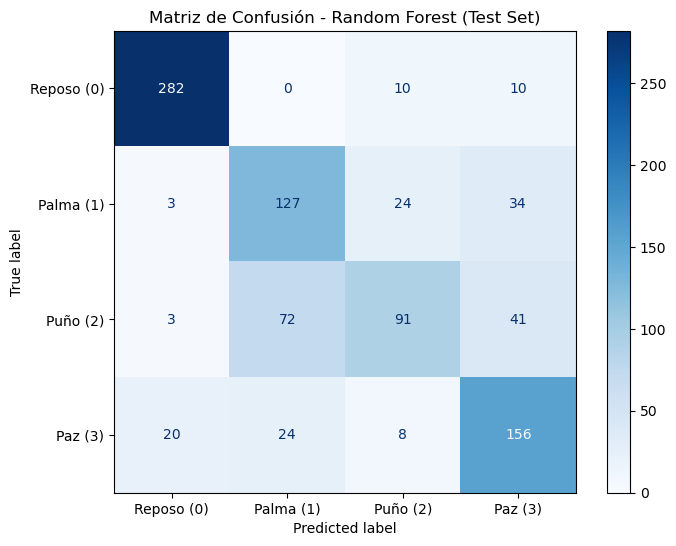

In [4]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"🎯 Test Accuracy: {acc*100:.2f}%")
print(f"🎯 Test F1-Score Macro: {f1:.4f}\n")

classes_names = ["Reposo (0)", "Palma (1)", "Puño (2)", "Paz (3)"]
print("--- Reporte de Clasificación Detallado ---")
print(classification_report(y_test, y_pred, target_names=classes_names))

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Matriz de Confusión - Random Forest (Test Set)")
plt.show()


## 5. Exportación del Modelo

In [5]:
# Crear el directorio si no existe
models_dir = os.path.join(os.environ["PROJECT_ROOT"], "intelligence", "models", "myotensor_proto", "ml")
os.makedirs(models_dir, exist_ok=True)

model_filename = 'rf_model.bin'
model_path = os.path.join(models_dir, model_filename)

print(f"💾 Guardando el clasificador RF optimizado en: {model_path} ...")
joblib.dump(best_rf, model_path)
print("✅ Modelo guardado con éxito.")


💾 Guardando el clasificador RF optimizado en: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/ml/rf_model.bin ...
✅ Modelo guardado con éxito.
